In [3]:
import pandas as pd
import joblib

df = pd.read_csv("../data/processed_telco.csv")

model = joblib.load("../models/churn_model.pkl")

In [4]:
X = df.drop("Churn", axis=1)

In [5]:
preprocessor = model.named_steps["preprocessor"]

X_transformed = preprocessor.transform(X)

In [6]:
import shap

classifier = model.named_steps["classifier"]

explainer = shap.LinearExplainer(
    classifier,
    X_transformed
)

shap_values = explainer.shap_values(
    X_transformed
)

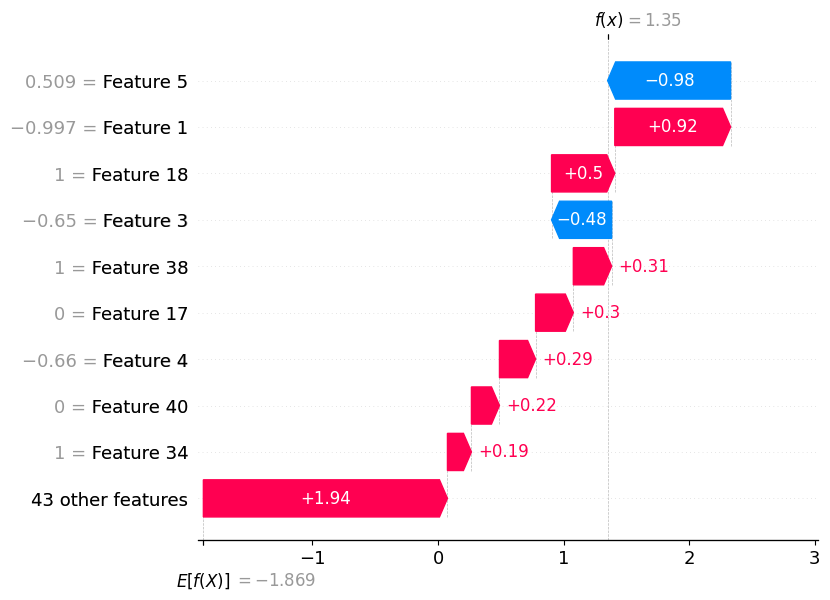

In [7]:
customer_idx = 5

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[customer_idx],
        base_values=explainer.expected_value,
        data=X_transformed[customer_idx]
    )
)

In [8]:
feature_names = preprocessor.get_feature_names_out()

len(feature_names)

52

In [9]:
X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=feature_names
)

In [10]:
explainer = shap.LinearExplainer(
    classifier,
    X_transformed_df
)

shap_values = explainer.shap_values(
    X_transformed_df
)

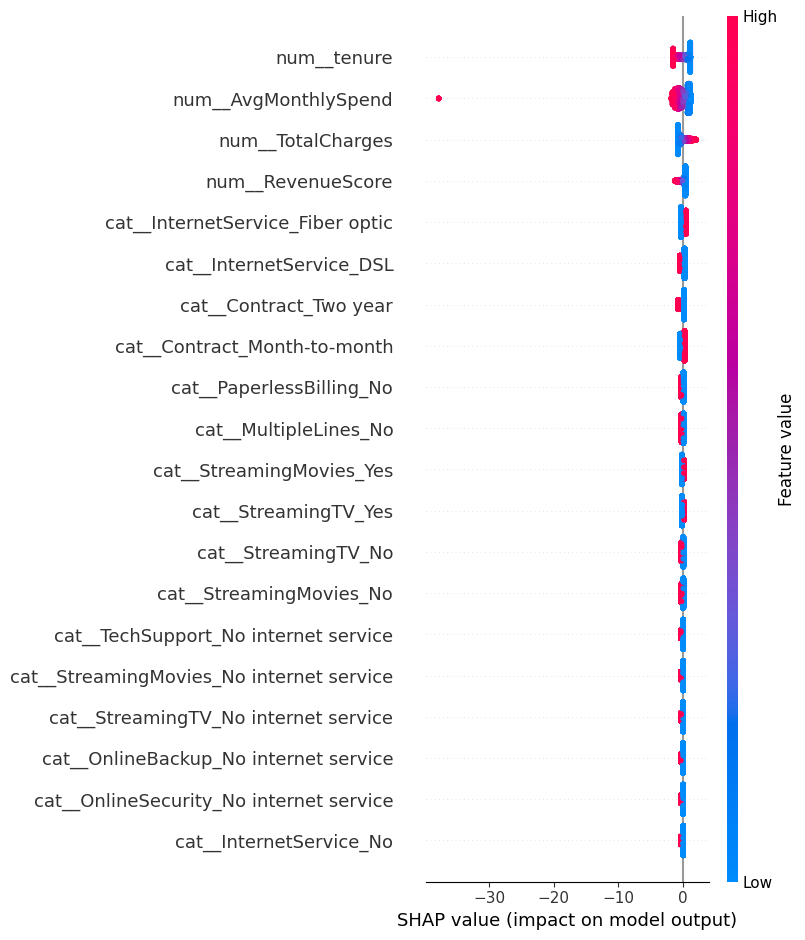

In [11]:
shap.summary_plot(
    shap_values,
    X_transformed_df
)

In [12]:
import joblib

joblib.dump(
    kmeans,
    "../models/kmeans_model.pkl"
)

NameError: name 'kmeans' is not defined

In [13]:
df["Cluster"].value_counts()

KeyError: 'Cluster'

In [14]:
import pandas as pd

df = pd.read_csv("../data/processed_telco.csv")

In [16]:
segmentation_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "RevenueScore"
]

X_seg = df[segmentation_features]

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_seg)

In [18]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

kmeans.fit(X_scaled)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [19]:
import joblib

joblib.dump(
    kmeans,
    "../models/kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "../models/segment_scaler.pkl"
)

['../models/segment_scaler.pkl']

In [20]:
import os

print(os.listdir("../models"))

['churn_model.pkl', 'kmeans_model.pkl', 'segment_scaler.pkl']
